In [1]:
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Extract zip
with zipfile.ZipFile('/content/archive (1).zip', 'r') as z:
    z.extractall('/content/')
    print("Files extracted:", z.namelist())

# Load dataset
df = pd.read_csv('/content/Titanic-Dataset.csv')

print("\nShape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Files extracted: ['Titanic-Dataset.csv']

Shape: (891, 12)

First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.100

In [2]:
# Step 1: Keep only useful columns
df = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Embarked', 'Fare']]
# We removed: PassengerId, Name, Ticket, Cabin, Survived
# These are useless for predicting Fare

print("Columns kept:", df.columns.tolist())

# Step 2: Handle missing values
df['Age'] = df['Age'].fillna(df['Age'].median())
# fill missing Age with median

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
# fill missing Embarked with most common port

# Step 3: Encode categorical columns
df['Sex'] = df['Sex'].map({'male': 1, 'female': 0})
# male → 1, female → 0

df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)
# Embarked → Embarked_Q and Embarked_S columns

df['Embarked_Q'] = df['Embarked_Q'].astype(int)
df['Embarked_S'] = df['Embarked_S'].astype(int)
# True/False → 1/0

print("\nData after preprocessing:")
print(df.head())
print("\nShape:", df.shape)
print("\nNull values:", df.isnull().sum().sum())

Columns kept: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Embarked', 'Fare']

Data after preprocessing:
   Pclass  Sex   Age  SibSp  Parch     Fare  Embarked_Q  Embarked_S
0       3    1  22.0      1      0   7.2500           0           1
1       1    0  38.0      1      0  71.2833           0           0
2       3    0  26.0      0      0   7.9250           0           1
3       1    0  35.0      1      0  53.1000           0           1
4       3    1  35.0      0      0   8.0500           0           1

Shape: (891, 8)

Null values: 0


In [3]:
# Separate features (X) and target (Y)
X = df.drop(columns=['Fare'])
# X → everything EXCEPT Fare
# these are the INPUTS to our model

Y = df['Fare']
# Y → only Fare column
# this is what we want to PREDICT

print("X shape:", X.shape)
print("Y shape:", Y.shape)

# Split into train and test sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
# test_size=0.2 → 20% data for testing, 80% for training
# random_state=42 → ensures same split every time you run

print("\nTraining size:", X_train.shape)
print("Testing size:", X_test.shape)

X shape: (891, 7)
Y shape: (891,)

Training size: (712, 7)
Testing size: (179, 7)


In [4]:
# Create the model
model = LinearRegression()
# LinearRegression() → creates an empty model ready to learn

# Train the model
model.fit(X_train, Y_train)
# fit() → model LEARNS the relationship between X and Y
# internally calculates best line that fits the training data

# Predict on test data
Y_pred = model.predict(X_test)
# predict() → uses learned relationship to predict Fare
# for the 179 unseen test rows

print("Model trained successfully! ✅")
print("\nFirst 5 Actual Fares:", list(Y_test[:5].values))
print("First 5 Predicted Fares:", list(Y_pred[:5].round(2)))


Model trained successfully! ✅

First 5 Actual Fares: [np.float64(15.2458), np.float64(10.5), np.float64(7.925), np.float64(33.0), np.float64(11.2417)]
First 5 Predicted Fares: [np.float64(34.9), np.float64(30.74), np.float64(-2.31), np.float64(47.21), np.float64(28.76)]


In [5]:
# Calculate evaluation metrics
mae = mean_absolute_error(Y_test, Y_pred)
# MAE → Mean Absolute Error
# average of |actual - predicted|
# tells us: "on average, how many dollars is our prediction off by?"

mse = mean_squared_error(Y_test, Y_pred)
# MSE → Mean Squared Error
# average of (actual - predicted)²
# penalizes BIG errors more heavily than small ones

rmse = np.sqrt(mse)
# RMSE → Root Mean Squared Error
# square root of MSE → brings back to original scale (dollars)
# easier to interpret than MSE

r2 = r2_score(Y_test, Y_pred)
# R² → R-squared score
# tells us: "how much % of Fare variation does our model explain?"
# range: 0 to 1 (closer to 1 = better model)

print("Model Evaluation:")
print(f"MAE  (Mean Absolute Error)  : {mae:.2f}")
print(f"MSE  (Mean Squared Error)   : {mse:.2f}")
print(f"RMSE (Root Mean Sq Error)   : {rmse:.2f}")
print(f"R²   (R-squared Score)      : {r2:.2f}")

Model Evaluation:
MAE  (Mean Absolute Error)  : 20.81
MSE  (Mean Squared Error)   : 928.61
RMSE (Root Mean Sq Error)   : 30.47
R²   (R-squared Score)      : 0.40


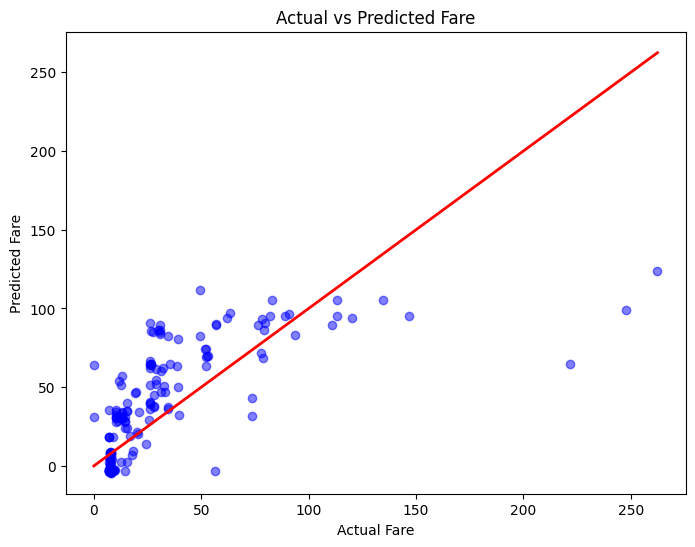

In [6]:
plt.figure(figsize=(8, 6))

plt.scatter(Y_test, Y_pred, color='blue', alpha=0.5)
# scatter plot → each dot = one passenger
# X axis → actual fare
# Y axis → predicted fare
# alpha=0.5 → makes dots slightly transparent

plt.plot([Y_test.min(), Y_test.max()],
         [Y_test.min(), Y_test.max()],
         color='red', linewidth=2)
# draws a PERFECT PREDICTION line (diagonal)
# if our model was perfect, all dots would sit ON this line

plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Actual vs Predicted Fare")
plt.show()

In [7]:
# Get coefficients of the model
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})
# coef_ → how much Fare changes for each unit increase in feature
# positive coefficient → feature increases Fare
# negative coefficient → feature decreases Fare

print("Model Coefficients:")
print(coefficients.sort_values('Coefficient', ascending=False))
# sort by coefficient value to see most impactful features

print(f"\nIntercept: {model.intercept_:.2f}")
# intercept → base Fare value when all features = 0

Model Coefficients:
      Feature  Coefficient
4       Parch    10.860994
3       SibSp     5.804953
2         Age    -0.079935
1         Sex    -3.606345
5  Embarked_Q   -13.938094
6  Embarked_S   -21.187405
0      Pclass   -33.932664

Intercept: 125.88
